---
title: Comparing the Ensemble Kalman Filter and the Particle Filter
jupyter: python3
execute:
  eval: false
---

::: {.callout-warning}
Epymorph's Bayesian filtering functionality is currently in beta and subject to change. 
:::

The `epymorph` package implements multiple techniques for state and parameter estimation. This notebook compares posterior estimates from the ensemble Kalman filter(EnKF) and particle filter(PF), two statistical filtering algorithms. The EnKF is an approximation to the Kalman filter, an algorithm for Bayesian filtering of linear and Gaussian state space models. Empirically, the EnKF performs well for weakly non-linear models by propagating a number of ensemble members through the Kalman update equations. As the EnKF requires a Gaussian likelihood we have also imposed such a likelihood on the PF for comparison. 


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from epymorph.kit import *
from epymorph.adrio import acs5

from epymorph.adrio import us_tiger

from epymorph.forecasting.pipeline import PipelineConfig, UnknownParam

from epymorph.forecasting.filter import ModelLink, Observations
from epymorph.forecasting.particle_filter import ParticleFilterSimulator

from epymorph.forecasting.dynamic_params import OrnsteinUhlenbeck
from epymorph.forecasting.dynamic_params import GaussianPrior, ExponentialTransform
from epymorph.forecasting.likelihood import NegativeBinomialLikelihood

from epymorph.initializer import RandomLocationsAndRandomSeed
from epymorph.forecasting.ensemble_kalman_filter import EnsembleKalmanFilterSimulator
from epymorph.attribute import NamePattern


### Exercise 1

We will first generate synthetic data from a multi-node simulation which includes the effects of movement. 

- [ ] Define the scope of simulation, the movement model, the ipm, the time frame, and the random number generator for both simulation and inference. 

In [2]:
scope = CountyScope.in_states(["AZ"], year=2015)
sim_movement_model = mm.Centroids()
sim_ipm = ipm.SIRH()
sim_time_frame = TimeFrame.of("2015-01-01", 26 * 7)
my_rng = np.random.default_rng(0)

We now generate the $\beta_t$ for each node in the simulation. In this example we are generating data for each Arizona county, so we have a $\beta_t$ for each. 

- [ ] Define the dynamics of the unknown transmission rate $\beta_t$. We choose stochastic process for $\beta_t$ exhibiting two key properties. Firstly the process is non-negative, meaning the disease transmission rate will never fall below zero. Secondly the process has a stationary distribution, meaning sample paths do not grow unbounded and have stable statistics. 

The process we choose here is a Black-Karasinski (BK) process, a stochastic process whose logarithm is an Ornstein-Uhlenbeck process. The dynamics are controlled by three parameters, the mean, the damping, and the standard deviation. The mean controls the mean of the logarithm of the stationary distribution, the damping controls the rate of mean reversion, and the standard deviation controls the standard deviation of the logarithm of the stationary distribution. The constants $A$,$M$, and $C$ are used to define the explicit discretization of the BK process utilized in the loop. 

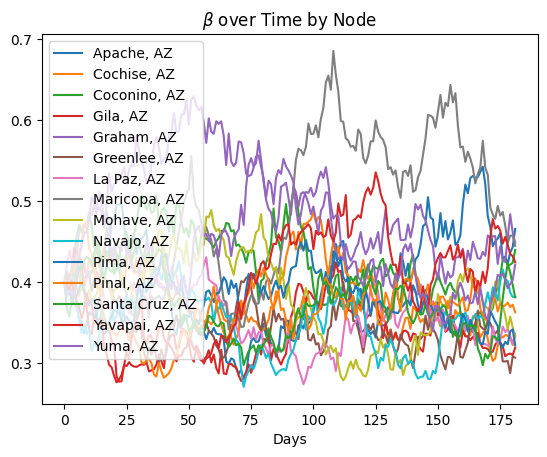

In [3]:
"""Generate a random time dependent beta"""

log_beta_damping = 1 / 35 * np.ones(scope.nodes)
log_beta_mean = np.log(0.4) * np.ones(scope.nodes)
log_beta_standard_deviation = 0.15 * np.ones(scope.nodes)
initial_log_beta = np.log(0.4) * np.ones(scope.nodes)

delta_t = 1.0

A = np.exp(-log_beta_damping * delta_t)
M = log_beta_mean * (np.exp(-log_beta_damping * delta_t) - 1)
C = log_beta_standard_deviation * np.sqrt(1 - np.exp(-2 * log_beta_damping * delta_t))

log_beta = np.zeros(
    (
        scope.nodes,
        sim_time_frame.duration_days,
    )
)
log_beta[:, 0] = initial_log_beta

for day in range(1, sim_time_frame.duration_days):
    log_beta[:, day] = (
        A * log_beta[:, day - 1] - M + C * my_rng.normal(size=(scope.nodes,))
    )

beta = np.exp(log_beta)

plt.title("$\\beta$ over Time by Node")
plt.xlabel("Days")
for node in range(scope.nodes):
    plt.plot(beta[node, :], label=f"{scope.labels[node]}")
plt.legend()
plt.show()

![](img/G3-enkf/bk_betas.png)

- [ ] Define the RUME used for simulation. We utilize a centroid based movement model and SIRH IPM. 

In [4]:
rume = SingleStrataRUME.build(
    ipm=sim_ipm,
    mm=sim_movement_model,
    scope=scope,
    init=init.IndexedLocations(selection=np.arange(scope.nodes), seed_size=10_000),
    time_frame=sim_time_frame,
    params={
        "beta": beta.T,
        "gamma": 0.1,
        "xi": 1 / 90,
        "phi": 5,
        "hospitalization_prob": 0.05,
        "hospitalization_duration": 5,
        "centroid": us_tiger.InternalPoint(),
        "population": acs5.Population(),
        "label": us_tiger.Name(),
    },
)

- [ ] Simulate the model to generate some synthetic data. The data will be the `I->H` event, the new hospitalizations per node per day. 

Loading gpm:all::mm::population (epymorph.adrio.acs5.Population):
  |####################| 100%  (1.507s)
Running simulation (BasicSimulator):
• 2015-01-01 to 2015-07-01 (182 days)
• 15 geo nodes
  |####################| 100%                     
Runtime: 0.552s


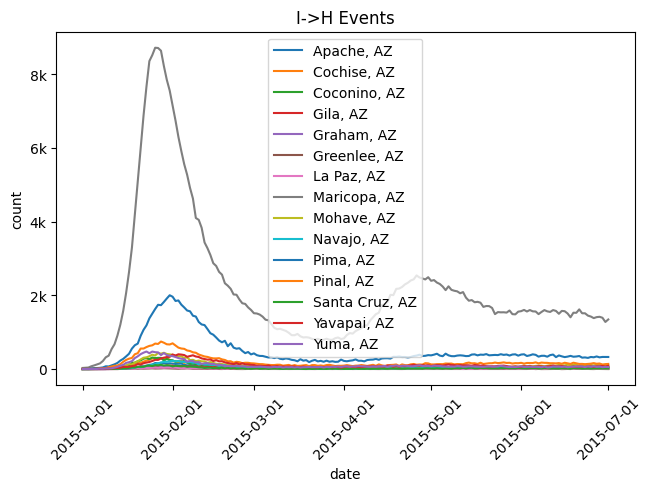

In [5]:
sim = BasicSimulator(rume)

with sim_messaging():
    out = sim.run(rng_factory=lambda: my_rng)

out.plot.line(
    geo=rume.scope.select.all(),
    time=rume.time_frame.select.all().group("day").agg(),
    quantity=rume.ipm.select.events("I->H"),
    title="I->H Events",
    label_format="{n}",
    legend="on",
)

![](img/G3-enkf/sim_data.png)

- [ ] Convert the data to a numpy array to be read by the particle filter. 

In [6]:
from epymorph.util import to_date_value_array
from epymorph.tools.data import munge

cases_df = munge(
    out,
    quantity=rume.ipm.select.events("I->H"),
    time=rume.time_frame.select.all().group("day").agg(),
    geo=rume.scope.select.all(),
)

cases_arr = to_date_value_array(
    cases_df["time"].to_numpy(), cases_df["I → H"].to_numpy()
).reshape(-1, rume.scope.nodes)

- [ ] Setup RUME for the inference problem. The IPM and movement model will be assumed to be known, and $\beta_t$ an unknown dynamic parameter.

In [7]:
num_realizations = 50

inf_rume = SingleStrataRUME.build(
    ipm=sim_ipm,
    mm=sim_movement_model,
    scope=scope,
    init=RandomLocationsAndRandomSeed(scope.nodes, 50_000),
    time_frame=sim_time_frame,
    params={
        "beta": ExponentialTransform("log_beta"),
        "gamma": 0.1,
        "xi": 1 / 90,
        "phi": 5,
        "hospitalization_prob": 0.05,
        "hospitalization_duration": 5,
        "centroid": us_tiger.InternalPoint(),
        "population": acs5.Population(),
        "label": us_tiger.Name(),
    },
)

- [ ] Setup the Observations object and define the unknown parameters. We utilize a Gaussian likelihood as the ensemble Kalman filter is restricted to Gaussian likelihoods. The Gaussian is parameterized by its variance, so the standard deviation of the observations is assumed to be $10.0$. The unknown parameters are defined as in previous examples, and we utilize the mean and standard deviation parameters of the simulated $\beta_t$'s. 

In [8]:
my_observations = Observations(
    source=cases_arr,
    model_link=ModelLink(
        geo=inf_rume.scope.select.all(),
        time=inf_rume.time_frame.select.all().group("day").agg(),
        quantity=inf_rume.ipm.select.events("I->H"),
    ),
    likelihood=NegativeBinomialLikelihood(r=10),
)

my_unknown_params = {
    "log_beta": UnknownParam(
        prior=GaussianPrior(
            mean=log_beta_mean,
            standard_deviation=log_beta_standard_deviation,
        ),
        dynamics=OrnsteinUhlenbeck(
            damping=log_beta_damping,
            mean=log_beta_mean,
            standard_deviation=log_beta_standard_deviation,
        ),
    )
}

- [ ] Define and run the EnKF and PF. 

In [9]:
from epymorph.forecasting.ensemble_kalman_filter import EnsembleKalmanFilterSimulator


enkf_simulator = EnsembleKalmanFilterSimulator(
    config=PipelineConfig.from_rume(
        inf_rume, num_realizations, unknown_params=my_unknown_params
    ),
    observations=my_observations,
)

pf_simulator = ParticleFilterSimulator(
    config=PipelineConfig.from_rume(
        inf_rume, num_realizations, unknown_params=my_unknown_params
    ),
    observations=my_observations,
)

In [10]:
from epymorph.log.messaging import pipeline_messaging


with pipeline_messaging(): 
    enkf_output = enkf_simulator.run(rng=my_rng)
    pf_output = pf_simulator.run(rng=my_rng)

Loading epymorph.adrio.acs5.Population:
  |####################| 100%  (0.836s)
Running simulation (EnsembleKalmanFilterSimulator):
• 2015-01-01 to 2015-07-01 (182 days)
• 15 geo nodes
• 50 realizations
  |####################| 100%                                   
Runtime: 84.185s
Running simulation (ParticleFilterSimulator):
• 2015-01-01 to 2015-07-01 (182 days)
• 15 geo nodes
• 50 realizations
  |####################| 100%                                   
Runtime: 83.122s


- [ ] Plot the posterior observations of the particle filter and ensemble Kalman filter with 95% credible intervals. We see a strong fit to the data with the ensemble Kalman filter whereas in some locations the particle filter has diverged. 

/tmp/ipykernel_18164/3082805215.py:71: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


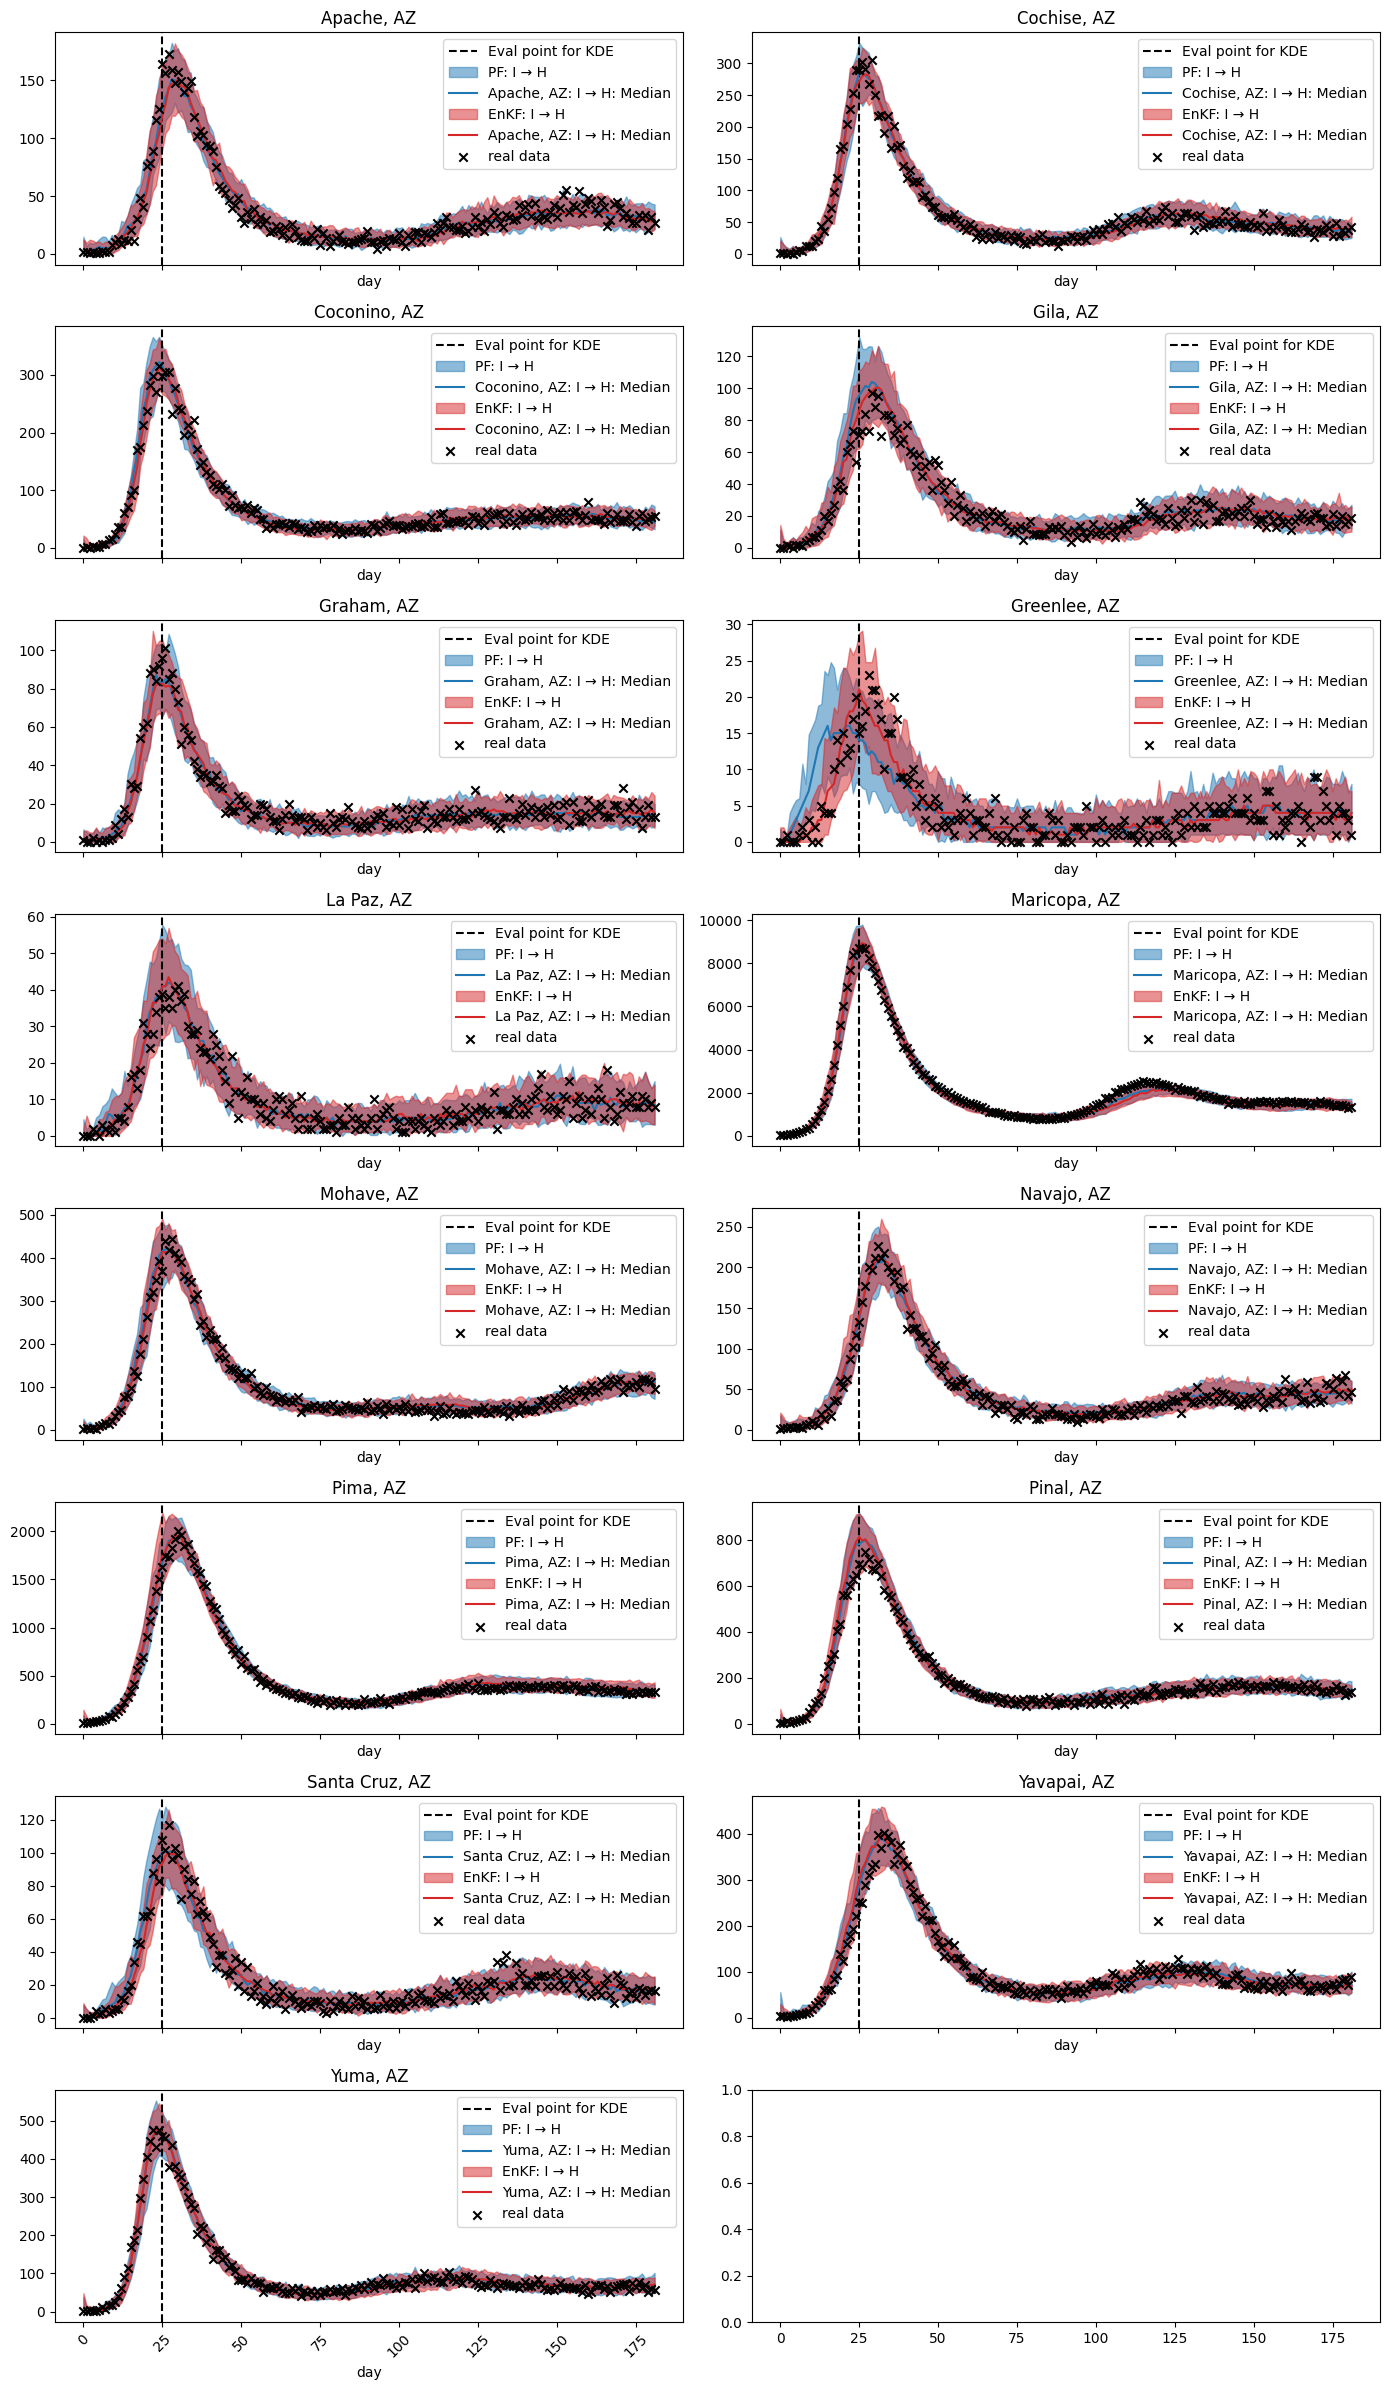

In [11]:
from math import ceil
from epymorph.forecasting.filter_plot import PlotRendererPipeline

eval_point = 25  # Day
geo = rume.scope.select.all()
quantity = rume.ipm.select.events("I->H")
time = rume.time_frame.select.all().group("day").agg()
data_date_range = np.arange(0, rume.time_frame.days, 1)

ncols = 2
nrows = ceil(geo.scope.nodes / ncols)
plotter1 = PlotRendererPipeline(pf_output)
plotter2 = PlotRendererPipeline(enkf_output)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols * 7, nrows * 3),
    sharex=True,
    layout="constrained",
)

realization = pf_output.select.all()
axes = axes.ravel()
for index in range(rume.scope.nodes):
    ax = axes[index]
    loc = rume.scope.labels[index]
    geo = rume.scope.select.by_county(loc)
    ax.axvline(eval_point, ls="dashed", color="black", label="Eval point for KDE")

    plotter1.quantiles_plt(
        ax,
        geo,
        time,
        quantity,
        legend="on",
        kwarg_type="geo",
        time_format="day",
        label_format="PF: {q}",
        fill_kwargs=[{"color": "tab:blue", "alpha": 0.5}],
        line_kwargs=[{"color": "tab:blue"}],
        credible_intervals=[95],
    )
    plotter2.quantiles_plt(
        ax,
        geo,
        time,
        quantity,
        legend="on",
        kwarg_type="geo",
        time_format="day",
        label_format="EnKF: {q}",
        fill_kwargs=[{"color": "tab:red", "alpha": 0.5}],
        line_kwargs=[{"color": "tab:red"}],
        credible_intervals=[95],
    )

    cases_loc = cases_df[cases_df["geo"] == geo.scope.node_ids[index]]

    ax.scatter(
        data_date_range,
        cases_loc["I → H"],
        marker="x",
        color="black",
        label="real data",
        zorder=100,
    )

    ax.set_title(f"{loc}")
    ax.legend()

fig.tight_layout()
plt.show()

![](img/G3-enkf/fit_of_data.png)

Both the PF and EnKF perform well overall, but the PF has divergence issues for Maricopa county. Due to the finite number of 
realizations in the PF this divergence can occur for high dimensional systems where PF effectively loses track of the state. The advantage of 
EnKF in this case is its ability to edit members of the ensemble to match the data, giving it much more flexibility. 

- [ ] Plot the posterior inference for $\beta_t$.

/tmp/ipykernel_18164/4198972196.py:64: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


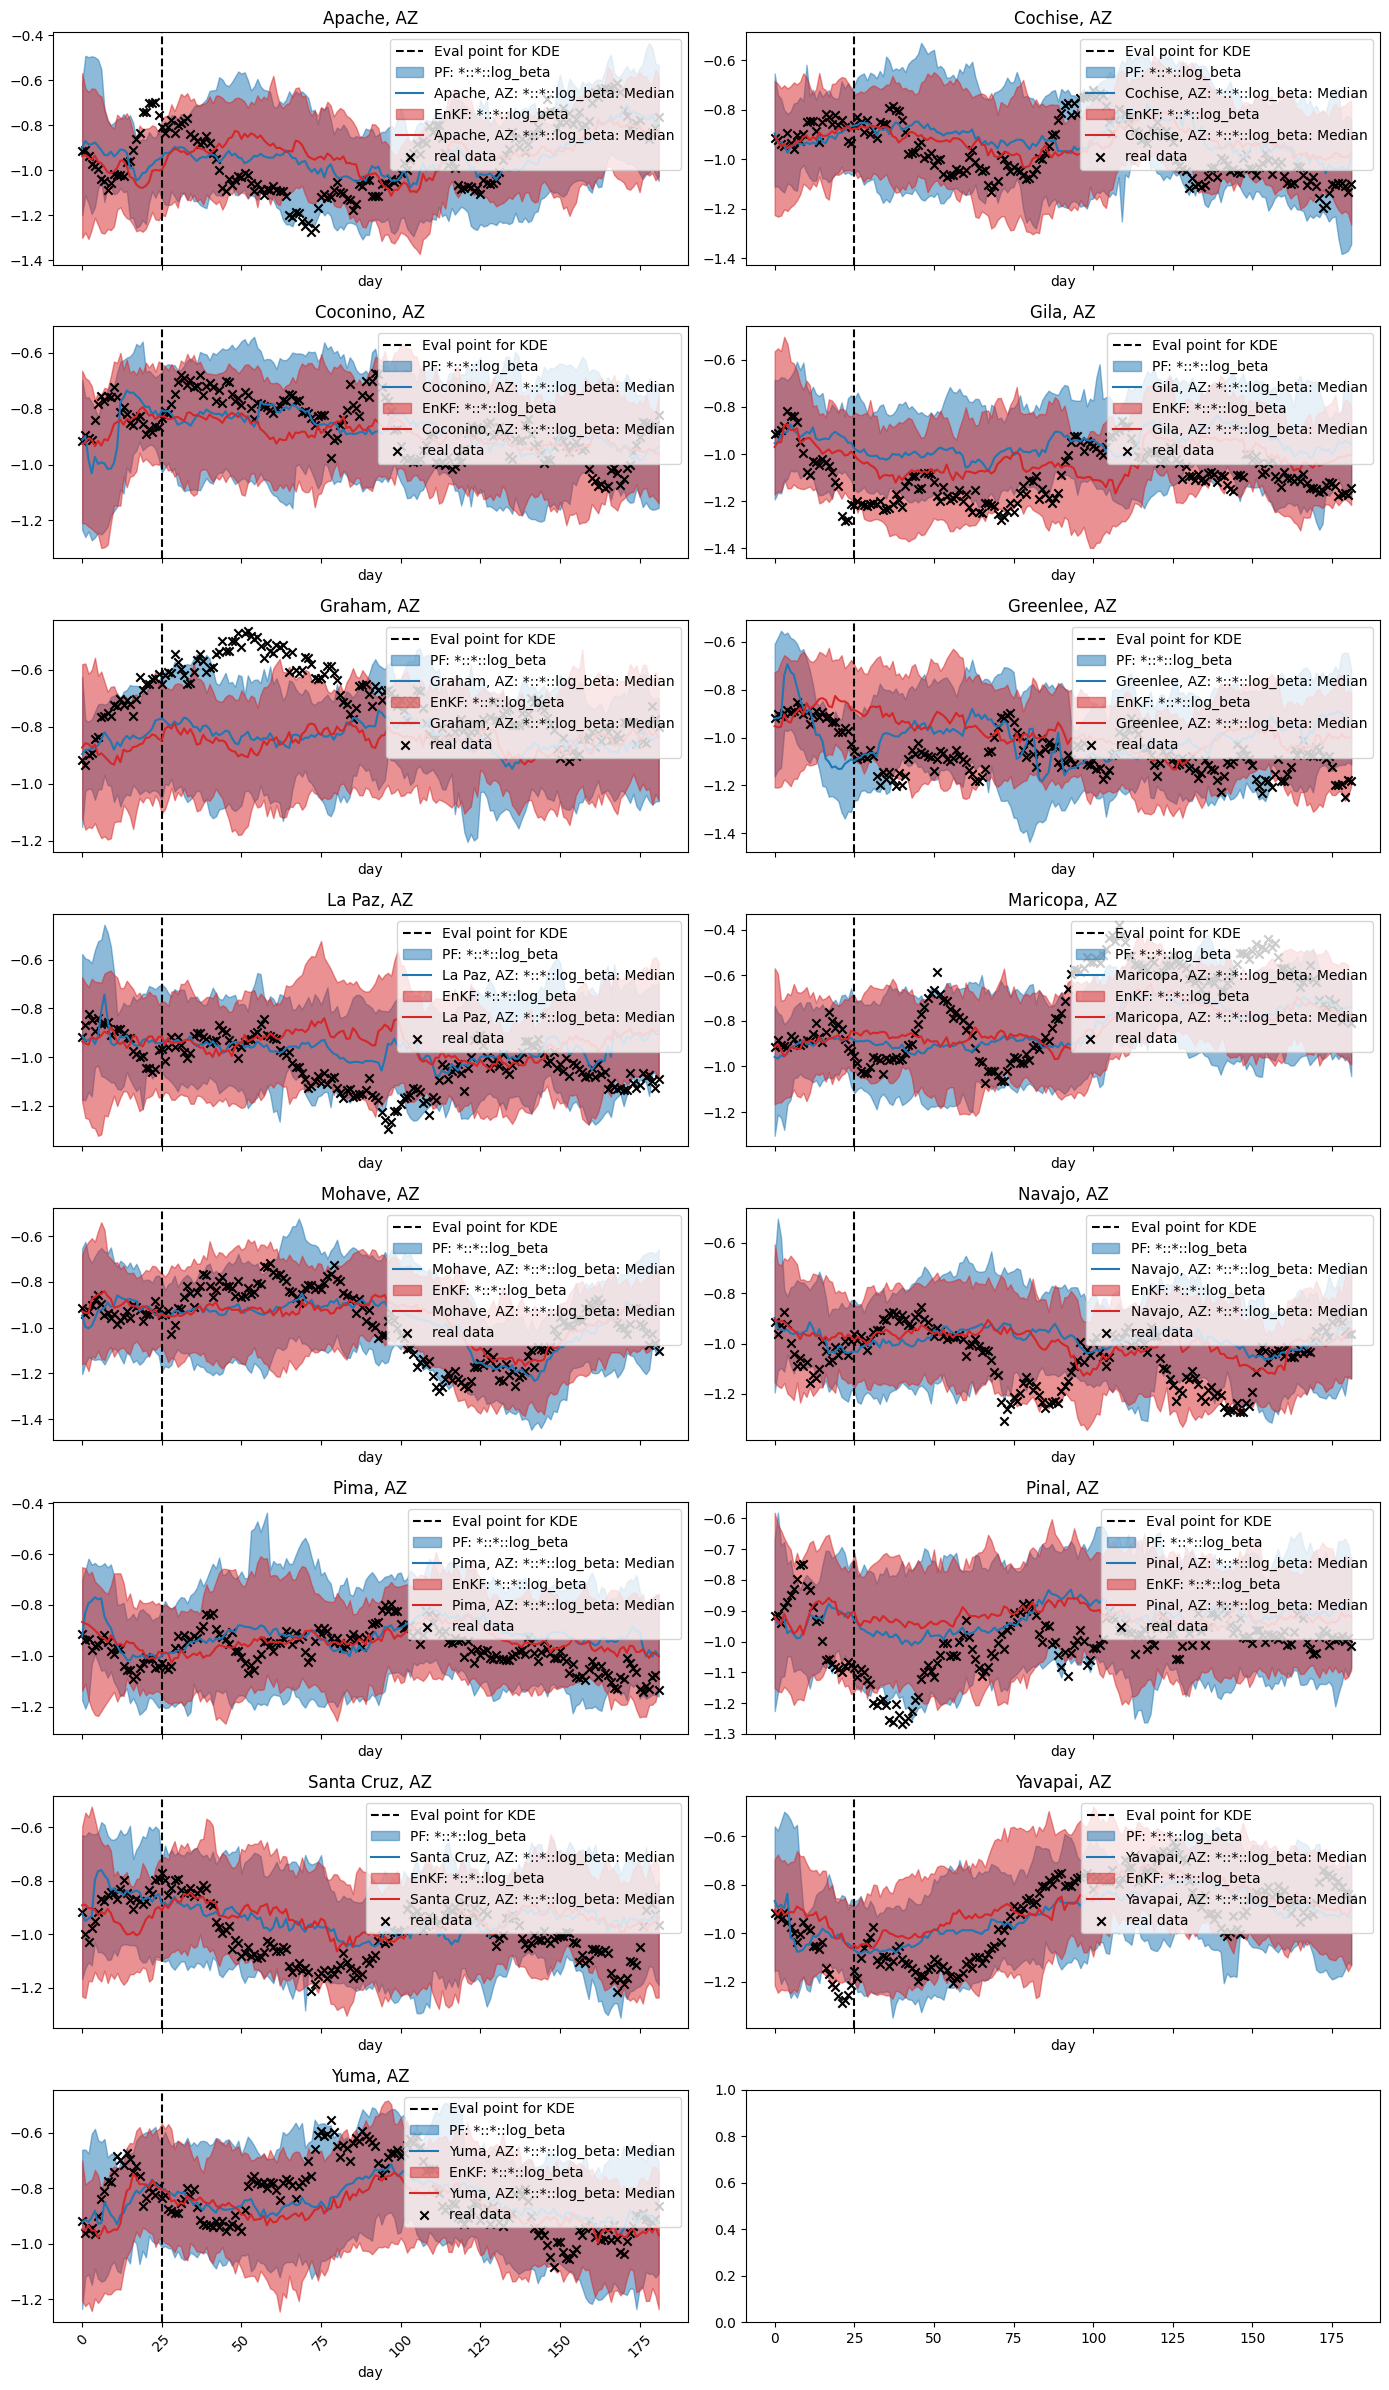

In [12]:
from math import ceil
from epymorph.forecasting.filter_plot import PlotRendererPipeline

eval_point = 25  # Day
geo = rume.scope.select.all()
time = rume.time_frame.select.all().group("day").agg()
quantity = pf_output.param_select.by_name("log_beta")
data_date_range = np.arange(0, rume.time_frame.days, 1)

ncols = 2
nrows = ceil(geo.scope.nodes / ncols)
plotter1 = PlotRendererPipeline(pf_output)
plotter2 = PlotRendererPipeline(enkf_output)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols * 7, nrows * 3),
    sharex=True,
    layout="constrained",
)

realization = pf_output.select.all()
axes = axes.ravel()
for index in range(rume.scope.nodes):
    ax = axes[index]
    loc = rume.scope.labels[index]
    geo = rume.scope.select.by_county(loc)
    ax.axvline(eval_point, ls="dashed", color="black", label="Eval point for KDE")
    plotter1.quantiles_plt(
        ax,
        geo,
        time,
        quantity,
        kwarg_type="geo",
        time_format="day",
        label_format="PF: {q}",
        fill_kwargs=[{"color": "tab:blue", "alpha": 0.5}],
        line_kwargs=[{"color": "tab:blue"}],
        credible_intervals=[95],
    )
    plotter2.quantiles_plt(
        ax,
        geo,
        time,
        quantity,
        kwarg_type="geo",
        time_format="day",
        label_format="EnKF: {q}",
        fill_kwargs=[{"color": "tab:red", "alpha": 0.5}],
        line_kwargs=[{"color": "tab:red"}],
        credible_intervals=[95],
    )
    ax.scatter(
        data_date_range,
        np.log(beta).T[:, index],
        label="real data",
        marker="x",
        color="black",
    )
    ax.set_title(f"{loc}")
    leg = ax.legend(loc='upper right')
    leg.set_zorder(2e10)

fig.tight_layout()
plt.show()

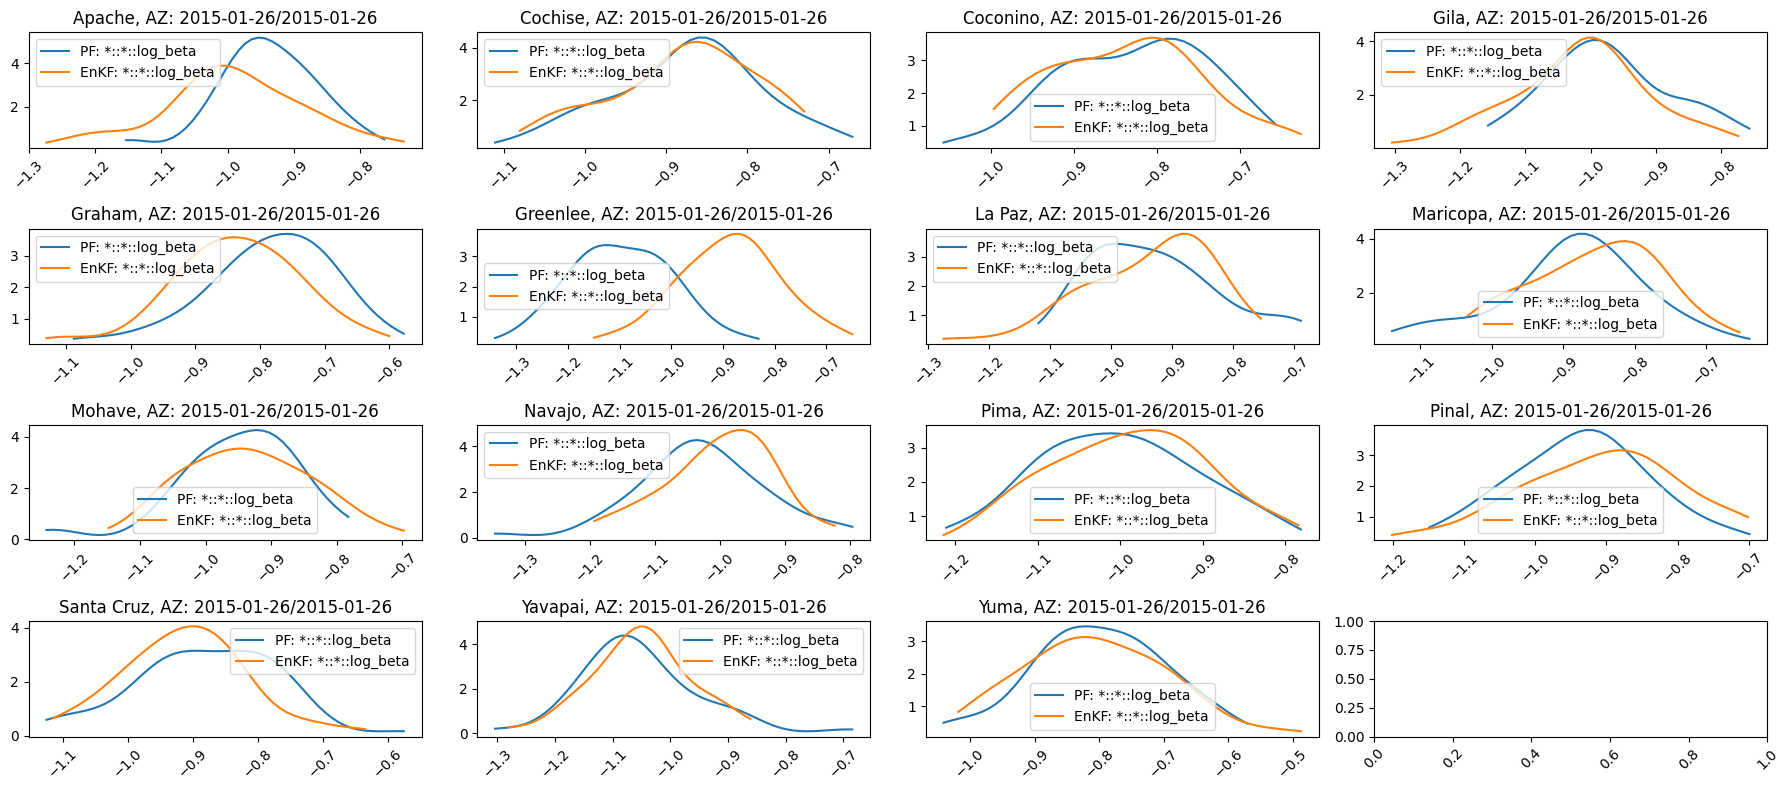

In [ ]:
from epymorph.forecasting.filter_plot import PlotRendererPipeline

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18, 8))
quantity = pf_output.param_select.by_name('log_beta')
geo = rume.scope.select.all()
time = rume.time_frame.select.days(eval_point, eval_point).group("day").agg()

plotter1.kde_plt(
    axes,
    geo,
    time,
    quantity,
    legend="on",
    label_format="PF",
    bandwidth="scott",
    delta_t=0.01,
    kwarg_type="geo",
)

plotter2.kde_plt(
    axes,
    geo,
    time,
    quantity,
    legend="on",
    label_format="EnKF",
    bandwidth="scott",
    delta_t=0.01,
    kwarg_type="geo",
)

fig.tight_layout()
plt.show()

![](img/G3-enkf/fit_of_beta.png)

## Notes 

The divergence of the particle filter for Maricopa county has also manifested in the estimation of $\beta_t$. The PF fails to capture the 
upwards trajectory of $\beta_t$ as opposed to the EnKF which provides a reasonable pathwise approximation. 
